# Week 1 live coding: arrays, dataframes, and plots

A 45-minute tutorial to type through together. It covers exactly the tools the optional coding review in Assignment 1
needs — NumPy arrays, pandas dataframes, matplotlib figures, and fitting a straight line.

We work with **global monthly methane (CH$_4$)** from NOAA. Assignment 1 uses the Mauna Loa
**CO$_2$** record, which has the same structure but is a different gas and a different file —
so everything you learn here transfers, and nothing here is the answer to the assignment.

```{admonition} How to use this notebook
:class: tip
Cells marked **Your turn** are deliberately empty. Try them before the answer goes up on the
screen. If you fall behind, the outputs are saved in this file — keep going and catch up
later.
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy", np.__version__)
print("pandas", pd.__version__)

numpy 1.26.4
pandas 2.3.3


## 1. NumPy arrays

A NumPy array is a grid of numbers of one type. Nearly all scientific Python sits on top of
it, including pandas.

**Creating arrays.** `arange` takes a *step*; `linspace` takes a *count*.

In [2]:
a = np.arange(12)          # 0, 1, 2, ... 11
b = np.linspace(0, 1, 5)   # exactly 5 values from 0 to 1 inclusive

print("arange: ", a)
print("linspace:", b)

arange:  [ 0  1  2  3  4  5  6  7  8  9 10 11]
linspace: [0.   0.25 0.5  0.75 1.  ]


**Shape and reshape.** The number of elements has to stay the same.

In [3]:
grid = np.arange(12).reshape(3, 4)
print(grid)
print("shape:", grid.shape)     # (rows, columns)

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
shape: (3, 4)


**Elementwise operations.** Arithmetic and functions apply to every element at once — no
loop. This is the whole point of NumPy.

In [4]:
x = np.linspace(0, 2 * np.pi, 9)
print("x       ", np.round(x, 2))
print("sin(x)  ", np.round(np.sin(x), 2))
print("2x + 1  ", np.round(2 * x + 1, 2))

x        [0.   0.79 1.57 2.36 3.14 3.93 4.71 5.5  6.28]
sin(x)   [ 0.    0.71  1.    0.71  0.   -0.71 -1.   -0.71 -0.  ]
2x + 1   [ 1.    2.57  4.14  5.71  7.28  8.85 10.42 12.   13.57]


**Boolean masks.** A comparison gives an array of `True`/`False`, which you can use to
select. This is how you filter without writing a loop.

In [5]:
mask = grid[:, 0] > 3          # look at the first column of each row
print("mask:", mask)
print(grid[mask])              # keep only the rows where the mask is True

mask: [False  True  True]
[[ 4  5  6  7]
 [ 8  9 10 11]]


Because `True` counts as 1, `.sum()` on a boolean array **counts** how many values satisfy a
condition.

In [6]:
s = np.sin(np.linspace(0, 4 * np.pi, 100))
print("values above zero:", (s > 0).sum(), "out of", s.size)

values above zero: 49 out of 100


**The `axis` argument — the one everybody gets wrong.**

`axis` names the dimension that gets **collapsed**, not the one that is kept.

In [7]:
print(grid)
print()
print("grid.mean(axis=0) ->", grid.mean(axis=0), "  collapses ROWS, one value per COLUMN")
print("grid.mean(axis=1) ->", grid.mean(axis=1), "      collapses COLUMNS, one value per ROW")

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

grid.mean(axis=0) -> [4. 5. 6. 7.]   collapses ROWS, one value per COLUMN
grid.mean(axis=1) -> [1.5 5.5 9.5]       collapses COLUMNS, one value per ROW


**Your turn.** Make an array of the integers 0–24, reshape it to 5×5, and print the mean of
each column. Check the length of your answer is 5.

## 2. Loading real data with pandas

NOAA publishes the global monthly methane record as a CSV with about 60 lines of header
comments. `comment="#"` skips them.

In [8]:
url = "https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.csv"
ch4 = pd.read_csv(url, comment="#")

print(ch4.shape)          # (rows, columns)
ch4.head()

(515, 7)


,year,month,decimal,average,average_unc,trend,trend_unc
0,1983,7,1983.542,1625.98,2.25,1635.14,1.50
1,1983,8,1983.625,1628.06,2.83,1635.64,1.44
2,1983,9,1983.708,1638.42,2.45,1636.19,1.36
3,1983,10,1983.792,1644.79,1.58,1636.82,1.27
4,1983,11,1983.875,1642.61,0.79,1637.52,1.18


Always look at what you loaded. The columns are:

| Column | Meaning |
| --- | --- |
| `year`, `month` | when |
| `decimal` | date as a fractional year, e.g. 1983.542 |
| `average` | global mean CH$_4$ that month, in parts per billion |
| `trend` | the same series with the seasonal cycle removed |
| `*_unc` | uncertainty on each |

In [9]:
print(ch4.dtypes)
print()
print("columns:", list(ch4.columns))

year             int64
month            int64
decimal        float64
average        float64
average_unc    float64
trend          float64
trend_unc      float64
dtype: object

columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']


**Checking for missing data.** Two different things to check, and only one of them is
obvious.

In [10]:
print("genuine NaNs per column:")
print(ch4.isna().sum())

genuine NaNs per column:
year           0
month          0
decimal        0
average        0
average_unc    0
trend          0
trend_unc      0
dtype: int64


That came back clean — but scientific datasets often code missing values as an *impossible
number* rather than leaving them blank. NOAA uses `-9.99` and similar in several of its
files. Always check the range as well as the NaN count.

In [11]:
print(ch4[["average", "trend"]].describe().round(2))
print()
print("any negative concentrations?", (ch4["average"] < 0).sum())

       average    trend
count   515.00   515.00
mean   1786.68  1786.68
std      74.98    74.81
min    1625.98  1635.14
25%    1741.10  1740.73
50%    1777.31  1775.15
75%    1833.82  1836.16
max    1945.45  1941.23

any negative concentrations? 0


**Making a real date column** so that plotting and time selection work properly.

In [13]:
ch4["date"] = pd.to_datetime(ch4["year"].astype(str) + "-" + ch4["month"].astype(str) + "-15")

print("records:", len(ch4))
print("from", ch4["date"].min().date(), "to", ch4["date"].max().date())

records: 515
from 1983-07-15 to 2026-05-15


**Your turn.** What were the lowest and highest monthly global CH$_4$ values in the record,
and when did each occur? (`.idxmin()` and `.idxmax()` give you the row label of the smallest
and largest entry.)

## 3. Plotting

Use the `fig, ax` form rather than bare `plt.plot`. Slightly more typing, and it scales to
multiple panels without rewriting anything.

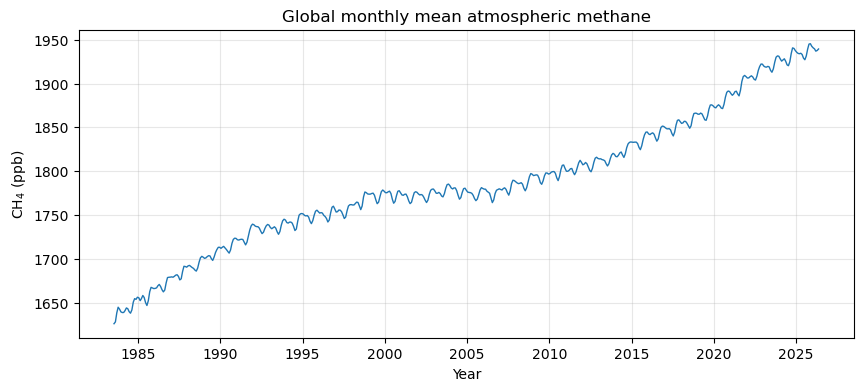

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ch4["date"], ch4["average"], lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("CH$_4$ (ppb)")            # ALWAYS include units
ax.set_title("Global monthly mean atmospheric methane")
ax.grid(alpha=0.3)
plt.show()

Every figure in this course needs **axis labels with units and a title**. This is not a style
preference — an unlabelled axis is the most common way a plot misleads the person who made
it.

**Two series on the same axes**: call `ax.plot` twice and give each a `label` so the legend
can tell them apart.

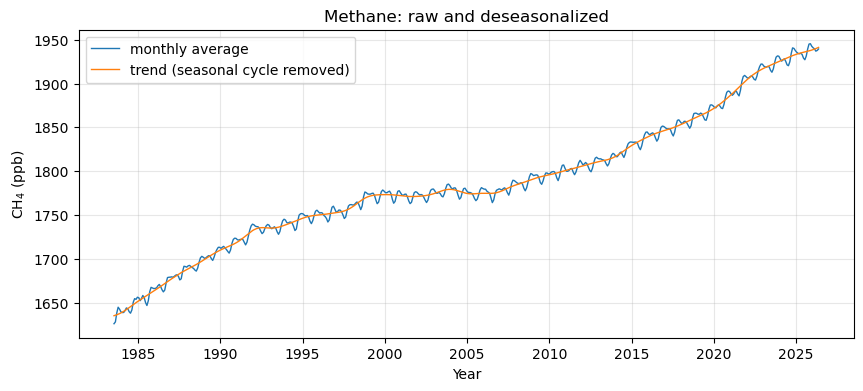

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ch4["date"], ch4["average"], lw=1, label="monthly average")
ax.plot(ch4["date"], ch4["trend"], lw=1, label="trend (seasonal cycle removed)")
ax.set_xlabel("Year")
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_title("Methane: raw and deseasonalized")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Zooming in.** Filter the dataframe rather than fighting with axis limits — then the y-axis
rescales to the window automatically.

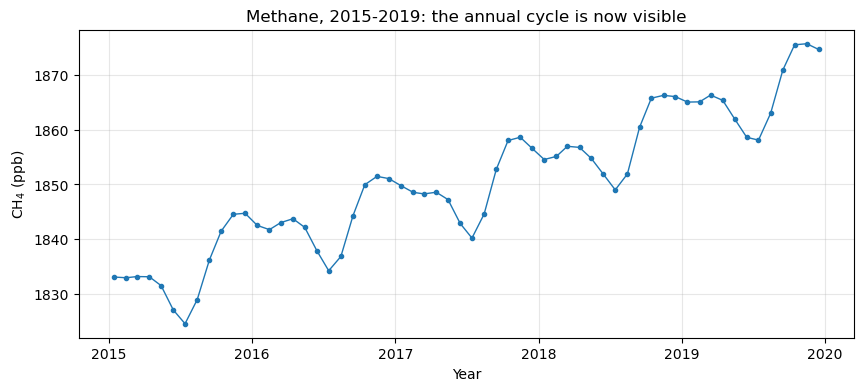

In [16]:
window = ch4[(ch4["year"] >= 2015) & (ch4["year"] <= 2019)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window["date"], window["average"], marker="o", ms=3, lw=1)
ax.set_xlabel("Year")
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_title("Methane, 2015-2019: the annual cycle is now visible")
ax.grid(alpha=0.3)
plt.show()

## 4. Grouping: the seasonal cycle and the growth rate

`groupby` splits rows into groups and applies an aggregation to each. It is how you compute a
climatology or an annual mean.

The seasonal cycle is what the trend column removed, so we can recover it by subtraction and
then average by calendar month.

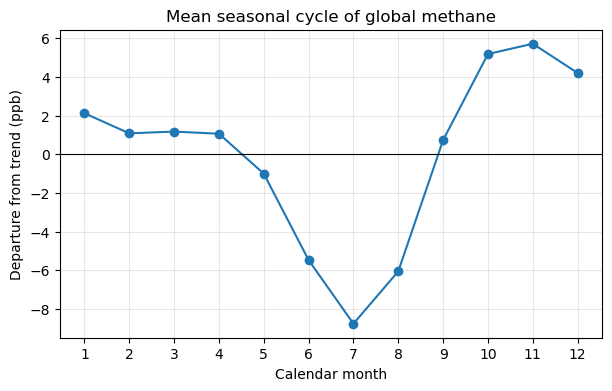

peak month:   11
trough month: 7
amplitude:    14.5 ppb


In [17]:
ch4["seasonal"] = ch4["average"] - ch4["trend"]
cycle = ch4.groupby("month")["seasonal"].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cycle.index, cycle.values, marker="o")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Calendar month")
ax.set_ylabel("Departure from trend (ppb)")
ax.set_title("Mean seasonal cycle of global methane")
ax.grid(alpha=0.3)
plt.show()

print("peak month:  ", cycle.idxmax())
print("trough month:", cycle.idxmin())
print("amplitude:   ", round(cycle.max() - cycle.min(), 1), "ppb")

**Annual means and year-over-year change.** `.diff()` gives the change from one row to the
next, which turns a series of annual means into a series of growth rates.

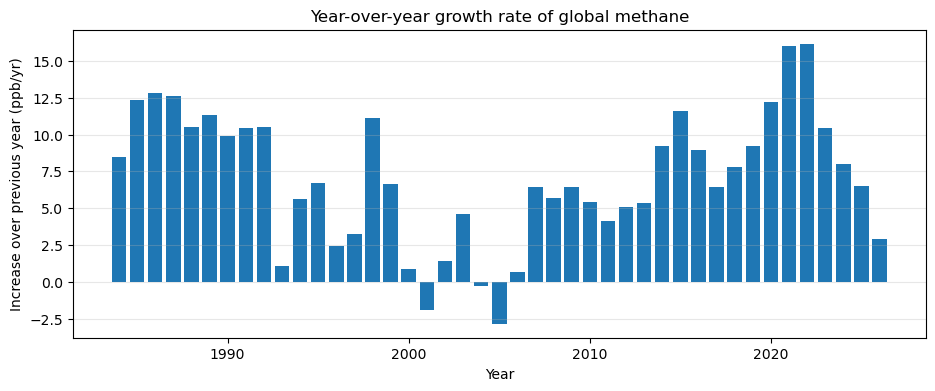

1984-1993 (rapid growth): 10.00 ppb/yr
2000-2006 (the stall)   :  0.38 ppb/yr
2014-2023 (resurgence)  : 10.80 ppb/yr


In [19]:
#counts = ch4.groupby("year")["average"].count()
#complete = counts[counts == 12].index          # only use full years
annual = ch4.groupby("year")["average"].mean()   #[ch4["year"].isin(complete)]
growth = annual.diff().dropna()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(growth.index, growth.values)
ax.set_xlabel("Year")
ax.set_ylabel("Increase over previous year (ppb/yr)")
ax.set_title("Year-over-year growth rate of global methane")
ax.grid(alpha=0.3, axis="y")
plt.show()

# Compare three periods rather than just the ends -- the interesting structure is in
# the middle, and a first-decade/last-decade comparison hides it completely.
for label, lo, hi in [("1984-1993 (rapid growth)", 1984, 1993),
                      ("2000-2006 (the stall)   ", 2000, 2006),
                      ("2014-2023 (resurgence)  ", 2014, 2023)]:
    period = growth[(growth.index >= lo) & (growth.index <= hi)]
    print(f"{label}: {period.mean():5.2f} ppb/yr")

Worth pausing on that plot. Methane growth nearly stalled in the early 2000s and then
accelerated sharply after 2007, with record growth around 2020-2021. Why that happened is an
open research question — wetland emissions, fossil fuel leakage, and changes in atmospheric
chemistry are all candidates. A single straight line through this record would hide all of
it.

**Your turn.** Which calendar month has the highest average CH$_4$ concentration (not the
highest seasonal departure — the highest raw `average`)? Does that surprise you, given the
trend?

## 5. Fitting a straight line

`np.polyfit` fits a polynomial of the degree you ask for and returns its coefficients,
highest power first. Degree 1 gives a slope and an intercept.

In [20]:
slope, intercept = np.polyfit(ch4["decimal"], ch4["average"], 1)

print(f"slope     = {slope:.2f} ppb per year")
print(f"intercept = {intercept:.1f} ppb")

slope     = 5.88 ppb per year
intercept = -9998.3 ppb


Those two numbers **are** the fitted model. You can evaluate them at any inputs you like —
including ones that were not part of the fit. That is what turns a description of past data
into a prediction.

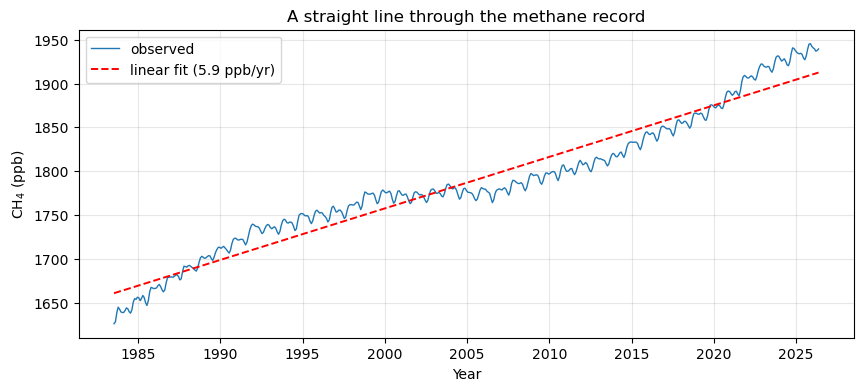

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ch4["date"], ch4["average"], lw=1, label="observed")
ax.plot(ch4["date"], slope * ch4["decimal"] + intercept, "r--", lw=1.4,
        label=f"linear fit ({slope:.1f} ppb/yr)")
ax.set_xlabel("Year")
ax.set_ylabel("CH$_4$ (ppb)")
ax.set_title("A straight line through the methane record")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Look at where the red line sits relative to the data. It is above the observations in the
middle of the record and below them at both ends — a systematic pattern in the residuals,
which is the signature of fitting a straight line to something curved.

That is the point Assignment 2 asks you to make for CO$_2$, and it is the first real idea in
this course: **a model can fit the data you gave it and still be the wrong shape.**

## Where this goes next

Everything above is mechanics. The optional coding review in Assignment 1 asks you to do the same operations on the Mauna
Loa CO$_2$ record, and Assignment 2 then asks what they mean — whether fitting a line counts as
machine learning at all, what a train/test split would look like for a time series, and why
extrapolating to 2100 is a fundamentally different problem from fitting 1958-2026.

If you want a fuller Python reference, see
[Computing and Research Methods for Climate Data Science](https://dmw2166.github.io/comp-res-climate-data-sci/intro.html).